Title: RL_data_analysis_NM_future.ipynb

Purpose: Analyse the basic residual load output from the SEM under 2K warming

Author: Onno Nennecke on 17.04.2025 Modified: 25.02.2026

Input data: 

- Adjusted Model output: model_output_all.nc
    - This file lies here: '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all_future.nc'

Output data:

- Plots: 2D_hist, Return_period_plot
    - These files lie here: /home/onennecke/Code/Figures/

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
import seaborn as sns

In [2]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all_future.nc'
files = [path]

ds = xr.open_dataset(path)

ts_datasets = ds.where((ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist'),drop=True)
ts_datasets.load()

ds_CMIP6 = ds.where((ds.ESM_run != 'ERA5_hist_week') & (ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist'),drop=True)
ds_CMIP6.load()


<xarray.Dataset> Size: 59MB
Dimensions:        (ESM_run: 192, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL...
    country        float64 8B 9.0
    period         <U4 16B 'week'
  * time           (time) datetime64[ns] 29kB 2039-01-01 ... 2048-12-31
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 6MB 1.208 -0.303 ... 6.245 7.776
    demand         (ESM_run, time) float64 6MB 1.505e+03 1.524e+03 ... 1.422e+03
    sfcWind        (ESM_run, time) float64 6MB 4.406 6.058 5.642 ... 6.601 8.858
    rsds           (ESM_run, time) float32 3MB 23.72 30.12 26.28 ... 32.49 20.75
    tas            (ESM_run, time) float32 3MB 1.553 0.233 ... 6.191 7.687
    tasmax         (ESM_run, time) float32 3MB 2.524 1.048 ... 9.226 9.364
    wind_off_prod  (ESM_run, time) float64 6MB 92.24 77.15 30.34 ... 166.3 147.1
    wind_on_prod   (ESM_run, time) float64 6MB 153.1 321.4 ... 539.8 1.166e+03
    solar_prod     (ESM_run, time) float64 6MB 38.47 53.53 46.18 ... 61.05 37.61
    total_prod     (ESM_run, time) float64 6MB 283.8 452.1 ... 767.1 1.351e+03
    Netto          (ESM_run, time) float64 6MB -1.221e+03 -1.072e+03 ... -71.73
    Residual_load  (ESM_run, time) float64 6MB 1.221e+03 1.072e+03 ... 71.73

In [3]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'
files = [path]

ds = xr.open_dataset(path)

ts_datasets_curr_clim = ds.where((ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist'),drop=True)
ts_datasets_curr_clim.load()
demand_curr_clim = ts_datasets_curr_clim['demand']

In [4]:
# Not important, just check how the new model changed the thresholds
'''ds_not_CESM = ds.where(~ds.ESM_run.str.startswith("CESM2_LE2") & (ds.ESM_run != 'SMARD_hist'), drop=True)
ds_not_CESM.load()

wind = ds_not_CESM['wind_off_prod'] + ds_not_CESM['wind_on_prod']
wind_on = ds_not_CESM['wind_on_prod']
wind_off = ds_not_CESM['wind_off_prod']
solar = ds_not_CESM['solar_prod']
total = ds_not_CESM['total_prod']
demand = ds_not_CESM['demand']
res_load = ds_not_CESM['Residual_load']

# Thresholds
wind_off_thresh = np.quantile(wind_off.values.flatten(), 0.05)
wind_on_thresh = np.quantile(wind_on.values.flatten(), 0.05)
wind_thresh = np.quantile(wind.values.flatten(), 0.05)
solar_thresh = np.quantile(solar.values.flatten(), 0.05)
total_thresh = np.quantile(total.values.flatten(), 0.05)
demand_thresh = np.quantile(demand.values.flatten(), 0.95)
res_load_thresh = np.quantile(res_load.values.flatten(), 0.95)

# Values for Solar, total and RL
print('Wind: ', wind_thresh)
print('Solar: ', solar_thresh)
print('Total: ', total_thresh)
print('Demand: ', demand_thresh)
print('Residual Load: ', res_load_thresh)'''

'ds_not_CESM = ds.where(~ds.ESM_run.str.startswith("CESM2_LE2") & (ds.ESM_run != \'SMARD_hist\'), drop=True)\nds_not_CESM.load()\n\nwind = ds_not_CESM[\'wind_off_prod\'] + ds_not_CESM[\'wind_on_prod\']\nwind_on = ds_not_CESM[\'wind_on_prod\']\nwind_off = ds_not_CESM[\'wind_off_prod\']\nsolar = ds_not_CESM[\'solar_prod\']\ntotal = ds_not_CESM[\'total_prod\']\ndemand = ds_not_CESM[\'demand\']\nres_load = ds_not_CESM[\'Residual_load\']\n\n# Thresholds\nwind_off_thresh = np.quantile(wind_off.values.flatten(), 0.05)\nwind_on_thresh = np.quantile(wind_on.values.flatten(), 0.05)\nwind_thresh = np.quantile(wind.values.flatten(), 0.05)\nsolar_thresh = np.quantile(solar.values.flatten(), 0.05)\ntotal_thresh = np.quantile(total.values.flatten(), 0.05)\ndemand_thresh = np.quantile(demand.values.flatten(), 0.95)\nres_load_thresh = np.quantile(res_load.values.flatten(), 0.95)\n\n# Values for Solar, total and RL\nprint(\'Wind: \', wind_thresh)\nprint(\'Solar: \', solar_thresh)\nprint(\'Total: \', tot

In [5]:
# All data
wind = ts_datasets['wind_off_prod'] + ts_datasets['wind_on_prod']
wind_on = ts_datasets['wind_on_prod']
wind_off = ts_datasets['wind_off_prod']
solar = ts_datasets['solar_prod']
total = ts_datasets['total_prod']
demand = ts_datasets['demand']
res_load = ts_datasets['Residual_load']

# Thresholds
wind_off_thresh = np.quantile(wind_off.values.flatten(), 0.05)
wind_on_thresh = np.quantile(wind_on.values.flatten(), 0.05)
wind_thresh = np.quantile(wind.values.flatten(), 0.05)
solar_thresh = np.quantile(solar.values.flatten(), 0.05)
total_thresh = np.quantile(total.values.flatten(), 0.05)
demand_thresh = np.quantile(demand.values.flatten(), 0.95)
res_load_thresh = np.quantile(res_load.values.flatten(), 0.95)

# Pull out the doy coordinate for x-axis
x = ts_datasets['doy']

# Compute the mean cycle (averaged over runs & years)
mean_wind_on  = wind_on.groupby(x).mean(dim=['ESM_run','time'])
mean_wind_off  = wind_off.groupby(x).mean(dim=['ESM_run','time'])
mean_wind  = wind.groupby(x).mean(dim=['ESM_run','time'])
mean_solar = solar.groupby(x).mean(dim=['ESM_run','time'])
mean_total = total.groupby(x).mean(dim=['ESM_run','time'])
mean_demand = demand.groupby(x).mean(dim=['ESM_run','time'])
mean_res_load = res_load.groupby(x).mean(dim=['ESM_run','time'])

# Compute the CMIP mean cycle 
wind_CMIP6 = ds_CMIP6['wind_off_prod'] + ds_CMIP6['wind_on_prod']
wind_on_CMIP6 = ds_CMIP6['wind_on_prod']
wind_off_CMIP6 = ds_CMIP6['wind_off_prod']
solar_CMIP6 = ds_CMIP6['solar_prod']
total_CMIP6 = ds_CMIP6['total_prod']
demand_CMIP6 = ds_CMIP6['demand']
res_load_CMIP6 = ds_CMIP6['Residual_load']


mean_wind_CMIP6  = wind_CMIP6.groupby(x).mean(dim=['ESM_run','time'])
mean_wind_on_CMIP6  = wind_on_CMIP6.groupby(x).mean(dim=['ESM_run','time'])
mean_wind_off_CMIP6  = wind_off_CMIP6.groupby(x).mean(dim=['ESM_run','time'])
mean_solar_CMIP6 = solar_CMIP6.groupby(x).mean(dim=['ESM_run','time'])
mean_total_CMIP6 = total_CMIP6.groupby(x).mean(dim=['ESM_run','time'])
mean_demand_CMIP6 = demand_CMIP6.groupby(x).mean(dim=['ESM_run','time'])
mean_res_load_CMIP6 = res_load_CMIP6.groupby(x).mean(dim=['ESM_run','time'])


In [6]:
# Values for Solar, total and RL
print('Wind: ', wind_thresh)
print('Solar: ', solar_thresh)
print('Total: ', total_thresh)
print('Demand: ', demand_thresh)
print('Residual Load: ', res_load_thresh)

Wind:  19.595153573716114
Solar:  32.476268777901204
Total:  159.23124326566185
Demand:  1515.8207324977002
Residual Load:  1310.5234128393997


In [7]:
# Old with old model
'''# Values for Solar, total and RL
print('Wind: ', wind_thresh)
print('Solar: ', solar_thresh)
print('Total: ', total_thresh)
print('Demand: ', demand_thresh)
print('Residual Load: ', res_load_thresh)'''

"# Values for Solar, total and RL\nprint('Wind: ', wind_thresh)\nprint('Solar: ', solar_thresh)\nprint('Total: ', total_thresh)\nprint('Demand: ', demand_thresh)\nprint('Residual Load: ', res_load_thresh)"

In [8]:
# For new model output
print(float(wind.max()))
print(float(solar.max()))
print(float(total.max()))
print(float(demand.max()))
print(float(res_load.max()))

1743.0216004079998
559.2279503795789
2186.813477367222
1702.5083202511773
1596.223514139268


In [9]:
def plot_winter_panel_with_months(ax, data, CMIP6_mean_cycle, ERA5_mean_cycle, SMARD_mean_cycle, title, nr_days_in_a_bin = 1, shift_days=182, SMARD = False):
    # --- Define histogram bins ---
    bin_size = int(np.floor(365/nr_days_in_a_bin))
    # print('Number of bins: ', bin_size)
    x_bins = np.linspace(x.min().values, x.max().values, bin_size)
    #    y‐bins: choose from 0 to a bit above your max production
    y_max = 2000# float(total.max())
    y_bins = np.linspace(0, y_max, 1710)
    
    
    # ---- prepare shifted x-axis ----
    doy = x.values
    doy_shift = ((doy + shift_days - 1) % 365) + 1

    # compute shifted & sorted bins
    x_bins_shift = ((x_bins + shift_days - 1) % 365) + 1
    order_bins = np.argsort(x_bins_shift)
    x_bins_rot = x_bins_shift[order_bins]

    # ---- 2D histogram ----
    X = np.tile(doy_shift, data.shape[0])
    Y = data.values.flatten()
    h = ax.hist2d(X, Y, bins=[x_bins_rot, y_bins],
                  norm=LogNorm(), cmap='inferno_r')

    # ---- shift & sort the mean cycles ----
    doy_mc = CMIP6_mean_cycle['doy'].values
    cmip6_vals   = CMIP6_mean_cycle.values
    era5_vals = ERA5_mean_cycle.values
    smr_vals  = SMARD_mean_cycle.values

    doy_mc_shift = ((doy_mc + shift_days - 1) % 365) + 1
    order = np.argsort(doy_mc_shift)

    ax.plot(doy_mc_shift[order], cmip6_vals[order],   c="#000000", lw=1.5, label='CMIP6 mean')
    ax.plot(doy_mc_shift[order], era5_vals[order], c='#0072B2', lw=1, label='ERA5 mean')
    if SMARD:
        ax.plot(doy_mc_shift[order], smr_vals[order],  c="#CC5A99", lw=1, label='SMARD mean')

    # ---- finalize axis limits & title ----
    ax.set_title(title, loc='left')
    ax.set_xlim(x_bins_rot.min(), x_bins_rot.max())
    # ax.set_xlabel('Shifted Day of Year (winter at center)')

    # ---- correct month‐name ticks on shifted axis ----
    # 1) true DOY for each month
    month_starts = {
        'Jan':   1,   'Feb':  32,  'Mar':  60,
        'Apr':  91,   'May': 121,  'Jun': 152,
        'Jul': 182,   'Aug': 213,  'Sep': 244,
        'Oct': 274,   'Nov': 305,  'Dec': 335
    }
    # 2) shift & wrap them
    xticks = [((d + shift_days - 1) % 365) + 1 for d in month_starts.values()]
    # 3) apply to axis
    ax.set_xticks(xticks)
    ax.set_xticklabels(month_starts.keys(), rotation=90) # , ha='right'

    # ax.legend()
    return h


In [10]:
def plot_winter_panel_with_months_new(ax, data, mean_cycle, title, nr_days_in_a_bin = 1, shift_days=182):
    # --- Define histogram bins ---
    bin_size = int(np.floor(365/nr_days_in_a_bin))
    # print('Number of bins: ', bin_size)
    x_bins = np.linspace(x.min().values, x.max().values, bin_size)
    #    y‐bins: choose from 0 to a bit above your max production
    y_max = 2000# float(total.max())
    y_bins = np.linspace(0, y_max, 1710)
    
    
    # ---- prepare shifted x-axis ----
    doy = x.values
    doy_shift = ((doy + shift_days - 1) % 365) + 1

    # compute shifted & sorted bins
    x_bins_shift = ((x_bins + shift_days - 1) % 365) + 1
    order_bins = np.argsort(x_bins_shift)
    x_bins_rot = x_bins_shift[order_bins]

    # ---- 2D histogram ----
    X = np.tile(doy_shift, data.shape[0])
    Y = data.values.flatten()
    h = ax.hist2d(X, Y, bins=[x_bins_rot, y_bins],
                  norm=LogNorm(), cmap='inferno_r')

    # ---- shift & sort the mean cycles ----
    doy_mc = mean_cycle['doy'].values
    mean_vals   = mean_cycle.values


    doy_mc_shift = ((doy_mc + shift_days - 1) % 365) + 1
    order = np.argsort(doy_mc_shift)

    ax.plot(doy_mc_shift[order], mean_vals[order],   c="#000000", lw=1.5, label='Mean')

    # ---- finalize axis limits & title ----
    ax.set_title(title, loc='left')
    ax.set_xlim(x_bins_rot.min(), x_bins_rot.max())
    # ax.set_xlabel('Shifted Day of Year (winter at center)')

    # ---- correct month‐name ticks on shifted axis ----
    # 1) true DOY for each month
    month_starts = {
        'Jan':   1,   'Feb':  32,  'Mar':  60,
        'Apr':  91,   'May': 121,  'Jun': 152,
        'Jul': 182,   'Aug': 213,  'Sep': 244,
        'Oct': 274,   'Nov': 305,  'Dec': 335
    }
    # 2) shift & wrap them
    xticks = [((d + shift_days - 1) % 365) + 1 for d in month_starts.values()]
    # 3) apply to axis
    ax.set_xticks(xticks)
    ax.set_xticklabels(month_starts.keys(), rotation=90) # , ha='right'

    # ax.legend()
    return h


In [11]:
# --- Make all text bigger (global defaults) ---
mpl.rcParams.update({
    'font.size': 14,         # base font size
    'axes.labelsize': 16,    # x/y labels
    'axes.titlesize': 18,    # axes titles (if used)
    'xtick.labelsize': 14,   # x tick labels
    'ytick.labelsize': 14,   # y tick labels
    'legend.fontsize': 16,   # legend text
    'figure.titlesize': 20,  # figure title (if used)
})

# --- Define histogram bins ---
nr_days_in_a_bin = 1
bin_size = int(np.floor(365/nr_days_in_a_bin))
print('Number of bins: ', bin_size)
x_bins = np.linspace(x.min().values, x.max().values, bin_size)
#    y‐bins: choose from 0 to a bit above your max production
y_max = 2000# float(total.max())
y_bins = np.linspace(0, y_max, 1710)
def plot_winter_panel_old_DOY(ax, data, mean_cycle, ERA5_mean_cycle, SMARD_mean_cycle, title, shift_days=182):
    # ---- prepare shifted x-axis ----
    doy = x.values
    doy_shift = ((doy + shift_days - 1) % 365) + 1

    # compute shifted & sorted bins
    x_bins_shift = ((x_bins + shift_days - 1) % 365) + 1
    order_bins = np.argsort(x_bins_shift)
    x_bins_rot = x_bins_shift[order_bins]

    # ---- 2D histogram ----
    X = np.tile(doy_shift, data.shape[0])
    Y = data.values.flatten()
    h = ax.hist2d(X, Y, bins=[x_bins_rot, y_bins],
                  norm=LogNorm(), cmap='inferno_r')

    # ---- shift & sort the mean cycles as plain numpy arrays ----
    doy_mc = mean_cycle['doy'].values
    mc_vals   = mean_cycle.values
    era5_vals = ERA5_mean_cycle.values
    smr_vals  = SMARD_mean_cycle.values

    doy_mc_shift = ((doy_mc + shift_days - 1) % 365) + 1
    order = np.argsort(doy_mc_shift)

    ax.plot(doy_mc_shift[order], mc_vals[order],   c='k', lw=2, label='mean')
    ax.plot(doy_mc_shift[order], era5_vals[order], c='w', lw=1, label='ERA5')
    ax.plot(doy_mc_shift[order], smr_vals[order],  c='r', lw=1, label='SMARD')

    # ---- finalize ----
    ax.set_title(title)
    ax.set_xlim(x_bins_rot.min(), x_bins_rot.max())
    ax.set_xlabel('Shifted day of year (winter at center)')
    ax.legend()
    return h


def plot_winter_panel_old_not_shifted(ax, data, mean_cycle, ERA5_mean_cycle, SMARD_mean_cycle, title):
    # Flatten to 1D for histogram
    X = np.tile(x.values, data.shape[0])
    Y = data.values.flatten()
    # 2D histogram with log scaling
    h = ax.hist2d(X, Y, bins=[x_bins, y_bins],
                  norm=LogNorm(), cmap='inferno_r')
    # Mark low‐end outliers (e.g. bottom 0.1 percentile)
    low = np.percentile(Y, 0.1)
    high = np.percentile(Y, 99.9)
    mask = (Y < low) | (Y > high)
    # ax.scatter(X[mask], Y[mask], s=3, c='b', alpha=0.4)
    # Mean winter cycle
    ax.plot(mean_cycle['doy'], mean_cycle, c='k', lw=2)
    # ERA5 mean winter cycle
    ax.plot(mean_cycle['doy'], ERA5_mean_cycle, c='w', lw=1)
    # SMARD mean winter cycle
    ax.plot(mean_cycle['doy'], SMARD_mean_cycle, c='r', lw=1)
    ax.set_title(title)
    ax.set_xlim(x_bins[0], x_bins[-1])
    ax.set_xlabel('Day of year')
    return h

Number of bins:  365


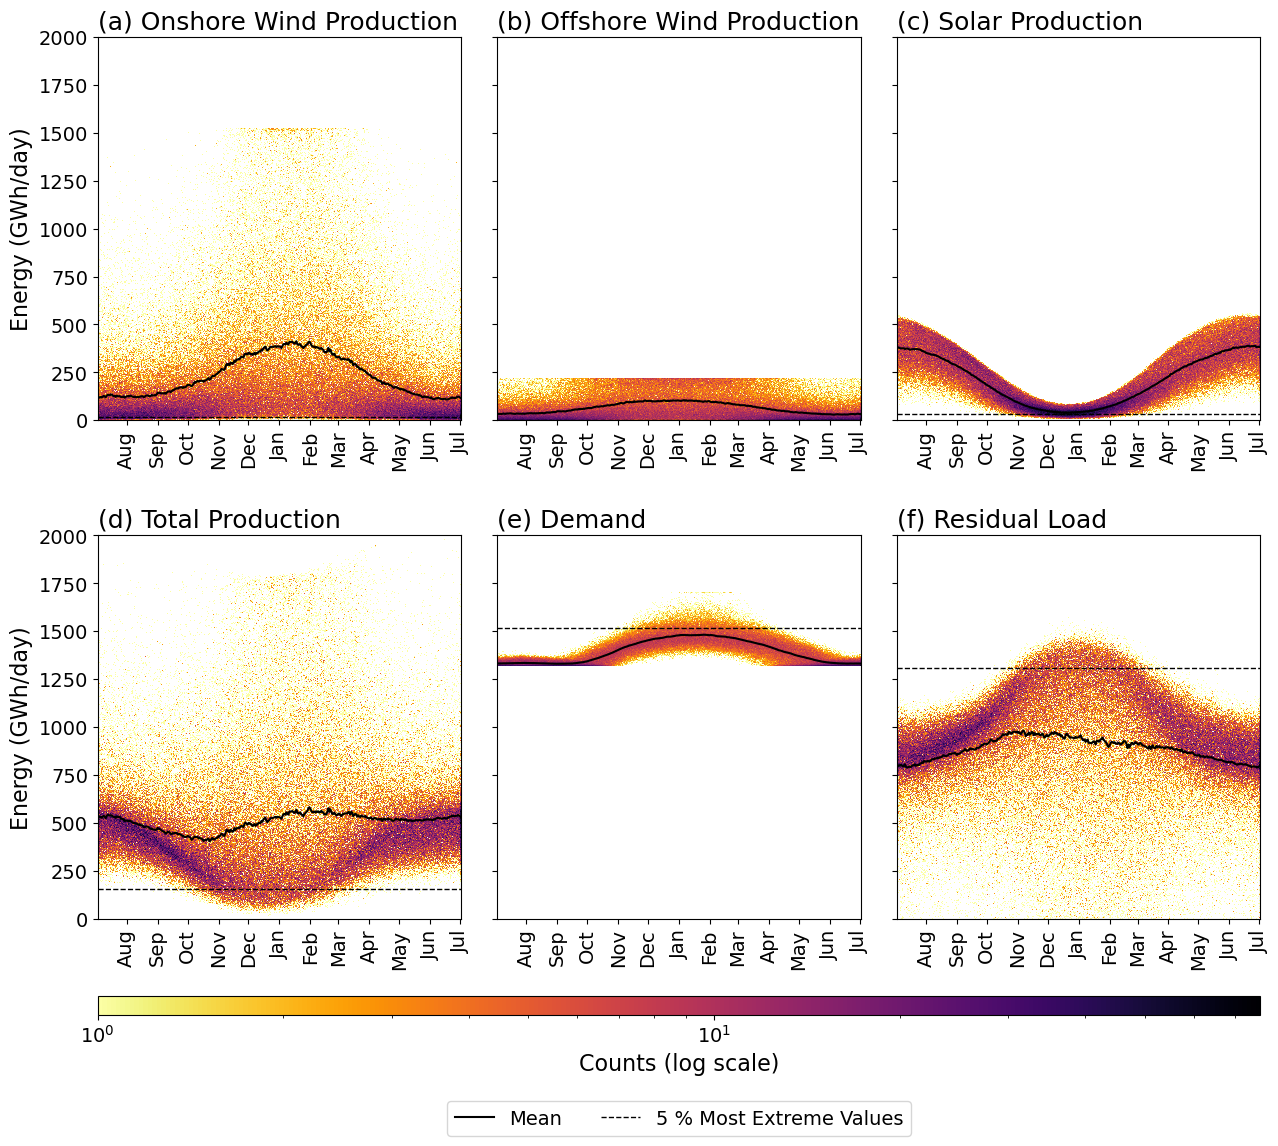

In [12]:
fig = plt.figure(figsize=(15, 14))

height_ratios = [1, 0.3, 1, 0.2, 0.05, 0.2, 0.06]
gs = GridSpec(nrows=7, ncols=3,
              height_ratios=height_ratios,
              hspace=0.0,
              wspace=0.1)

# --- create top row, sharing y-axis across the row ---
axes_top = []
# first top axis
ax0 = fig.add_subplot(gs[0, 0])
axes_top.append(ax0)
# share y with the first top axis for the remaining top axes
axes_top.append(fig.add_subplot(gs[0, 1], sharey=ax0))
axes_top.append(fig.add_subplot(gs[0, 2], sharey=ax0))

# --- create bottom row, sharing y-axis across that row ---
axes_bottom = []
ax2_0 = fig.add_subplot(gs[2, 0])
axes_bottom.append(ax2_0)
axes_bottom.append(fig.add_subplot(gs[2, 1], sharey=ax2_0))
axes_bottom.append(fig.add_subplot(gs[2, 2], sharey=ax2_0))

# example calls to your plotting function (use your function as before)
h1 = plot_winter_panel_with_months_new(axes_top[0], wind_on, mean_wind_on, '(a) Onshore Wind Production', nr_days_in_a_bin=1)
h2 = plot_winter_panel_with_months_new(axes_top[1], wind_off, mean_wind_off, '(b) Offshore Wind Production', nr_days_in_a_bin=1)
h3 = plot_winter_panel_with_months_new(axes_top[2], solar, mean_solar, '(c) Solar Production', nr_days_in_a_bin=1)
h4 = plot_winter_panel_with_months_new(axes_bottom[0], total, mean_total, '(d) Total Production', nr_days_in_a_bin=1)
h5 = plot_winter_panel_with_months_new(axes_bottom[1], demand, mean_demand, '(e) Demand', nr_days_in_a_bin=1)
h6 = plot_winter_panel_with_months_new(axes_bottom[2], res_load, mean_res_load, '(f) Residual Load', nr_days_in_a_bin=1)

# show y-label only on left-most axes (since the row shares y)
axes_top[0].set_ylabel('Energy (GWh/day)')
axes_bottom[0].set_ylabel('Energy (GWh/day)')

# hide y-tick labels on the other axes in the same row to avoid duplicate labels
for ax in axes_top[1:]:
    ax.tick_params(labelleft=False)
for ax in axes_bottom[1:]:
    ax.tick_params(labelleft=False)

# colorbar (row 4)
cax = fig.add_subplot(gs[4, :])
cb = plt.colorbar(h3[3], cax=cax, orientation='horizontal')
cb.set_label('Counts (log scale)')

# legend row (row 6)
legend_ax = fig.add_subplot(gs[6, :])
legend_ax.axis('off')

# thresholds and legend handling
axes_top[0].axhline(wind_on_thresh, ls='--', color='k', lw=1, label='5 % Most Extreme Values')
axes_top[1].axhline(wind_off_thresh, ls='--', color='k', lw=1)
axes_top[2].axhline(solar_thresh, ls='--', color='k', lw=1)
axes_bottom[0].axhline(total_thresh, ls='--', color='k', lw=1)
axes_bottom[1].axhline(demand_thresh, ls='--', color='k', lw=1)
axes_bottom[2].axhline(res_load_thresh, ls='--', color='k', lw=1)

handles, labels = axes_top[0].get_legend_handles_labels()
legend_ax.legend(handles, labels, loc='upper center', ncol=3, frameon=True, fontsize='medium')

# Save plot
# plt.savefig('/home/onennecke/Code/Figures/2D_hist_6_plts.png', bbox_inches='tight', dpi=300)

plt.show()


In [13]:
# Dates of the highest mean residual load values
top10_idx = mean_res_load.values.argsort()[-10:][::-1]
for idx in top10_idx:
    doy = mean_res_load['doy'].values[idx]
    val = mean_res_load.values[idx]
    date_matches = ts_datasets['time'].values[ts_datasets['doy'].values == doy][0]
    print(f"Value: {val:.2f} at DOY {doy} (dates: {pd.to_datetime(date_matches).strftime('%m-%d')})")

Value: 982.91 at DOY 311 (dates: 11-07)
Value: 980.62 at DOY 310 (dates: 11-06)
Value: 977.58 at DOY 301 (dates: 10-28)
Value: 977.12 at DOY 304 (dates: 10-31)
Value: 976.26 at DOY 302 (dates: 10-29)
Value: 976.24 at DOY 296 (dates: 10-23)
Value: 975.78 at DOY 319 (dates: 11-15)
Value: 975.65 at DOY 342 (dates: 12-08)
Value: 975.39 at DOY 306 (dates: 11-02)
Value: 975.16 at DOY 303 (dates: 10-30)


In [14]:
# Show all doys of extreme residual load days (days above threshold)
extreme_res_load = res_load.where(res_load >= res_load_thresh, drop=True)
unique_extreme_doys_RL = np.unique(extreme_res_load['doy'].values) # Get all unique day-of-year values for extreme res_load days
print(unique_extreme_doys_RL)

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  92  93 100 102 112 114 281 286 288 289 290 291 292 293 294 295 296 297
 298 299 300 301 302 303 304 305 306 307 308 309 310 311 312 313 314 315
 316 317 318 319 320 321 322 323 324 325 326 327 328 329 330 331 332 333
 334 335 336 337 338 339 340 341 342 343 344 345 346 347 348 349 350 351
 352 353 354 355 356 357 358 359 360 361 362 363 364 365]


In [15]:
# Print dates of the first and last extreme day in the year
date_100 = pd.to_datetime(ts_datasets['time'].values[ts_datasets['doy'].values == 100][0])
date_286 = pd.to_datetime(ts_datasets['time'].values[ts_datasets['doy'].values == 286][0])
print(f"DOY 100: {date_100.strftime('%Y-%m-%d')}")
print(f"DOY 286: {date_286.strftime('%Y-%m-%d')}")

DOY 100: 2039-04-10
DOY 286: 2039-10-13


In [16]:
# Dates of the highest residual load values
top10_idx = np.argpartition(res_load.values.ravel(), -10)[-10:]
top10_idx = top10_idx[np.argsort(res_load.values.ravel()[top10_idx])[::-1]]  # sort descending
repeated_vector = np.tile(res_load['time'].values, (len(res_load.ESM_run), 1)).ravel()

for idx in top10_idx:
    max_date = repeated_vector[idx]
    print(pd.to_datetime(max_date).strftime('%Y-%m-%d'))

2042-12-23
2048-12-21
2041-12-30
2046-12-22
2042-01-07
2045-01-11
2042-01-15
2042-01-06
2041-12-29
2045-01-13


In [17]:
# Show all doys of extreme demand days (days above threshold)
extreme_demand = demand.where(demand >= demand_thresh, drop=True)
unique_extreme_doys = np.unique(extreme_demand['doy'].values) # Get all unique day-of-year values for extreme demand days
unique_extreme_doys

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 118, 294, 296, 297, 299, 300, 301, 303, 304, 305,
       306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318,
       319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331,
       332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344,
       345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357,
       358, 359, 360, 361, 362, 363, 364, 365])

In [18]:
# Print dates of the first and last extreme day in the year
100
286
date_100 = pd.to_datetime(ts_datasets['time'].values[ts_datasets['doy'].values == 118][0])
date_286 = pd.to_datetime(ts_datasets['time'].values[ts_datasets['doy'].values == 294][0])
print(f"DOY 100: {date_100.strftime('%Y-%m-%d')}")
print(f"DOY 286: {date_286.strftime('%Y-%m-%d')}")

DOY 100: 2039-04-28
DOY 286: 2039-10-21


In [19]:
# Dates of the highest mean demand values
top10_idx = mean_total.values.argsort()[:10][::1]
for idx in top10_idx:
    doy = mean_total['doy'].values[idx]
    val = mean_total.values[idx]
    date_matches = ts_datasets['time'].values[ts_datasets['doy'].values == doy][0]
    print(f"Value: {val:.2f} at DOY {doy} (dates: {pd.to_datetime(date_matches).strftime('%m-%d')})")

Value: 405.86 at DOY 296 (dates: 10-23)
Value: 406.58 at DOY 290 (dates: 10-17)
Value: 409.69 at DOY 297 (dates: 10-24)
Value: 411.79 at DOY 291 (dates: 10-18)
Value: 412.03 at DOY 293 (dates: 10-20)
Value: 412.67 at DOY 292 (dates: 10-19)
Value: 413.37 at DOY 278 (dates: 10-05)
Value: 415.06 at DOY 289 (dates: 10-16)
Value: 415.56 at DOY 301 (dates: 10-28)
Value: 415.93 at DOY 300 (dates: 10-27)


In [20]:
# Dates of the lowest mean solar production values
top10_idx = mean_solar.values.argsort()[:10][::1]
for idx in top10_idx:
    doy = mean_solar['doy'].values[idx]
    val = mean_solar.values[idx]
    date_matches = ts_datasets['time'].values[ts_datasets['doy'].values == doy][0]
    print(f"Value: {val:.2f} at DOY {doy} (dates: {pd.to_datetime(date_matches).strftime('%m-%d')})")

Value: 40.33 at DOY 355 (dates: 12-21)
Value: 40.35 at DOY 357 (dates: 12-23)
Value: 40.45 at DOY 356 (dates: 12-22)
Value: 40.52 at DOY 351 (dates: 12-17)
Value: 40.58 at DOY 354 (dates: 12-20)
Value: 40.66 at DOY 359 (dates: 12-25)
Value: 40.69 at DOY 358 (dates: 12-24)
Value: 40.88 at DOY 349 (dates: 12-15)
Value: 40.88 at DOY 352 (dates: 12-18)
Value: 40.90 at DOY 353 (dates: 12-19)


In [21]:
# Dates of the lowest mean wind production values
top10_idx = mean_wind.values.argsort()[:10][::1]
for idx in top10_idx:
    doy = mean_wind['doy'].values[idx]
    val = mean_wind.values[idx]
    date_matches = ts_datasets['time'].values[ts_datasets['doy'].values == doy][0]
    print(f"Value: {val:.2f} at DOY {doy} (dates: {pd.to_datetime(date_matches).strftime('%m-%d')})")

Value: 139.44 at DOY 168 (dates: 06-17)
Value: 139.84 at DOY 169 (dates: 06-18)
Value: 140.15 at DOY 156 (dates: 06-05)
Value: 140.63 at DOY 170 (dates: 06-19)
Value: 140.76 at DOY 164 (dates: 06-13)
Value: 141.06 at DOY 155 (dates: 06-04)
Value: 141.43 at DOY 165 (dates: 06-14)
Value: 141.78 at DOY 163 (dates: 06-12)
Value: 142.54 at DOY 157 (dates: 06-06)
Value: 142.89 at DOY 171 (dates: 06-20)


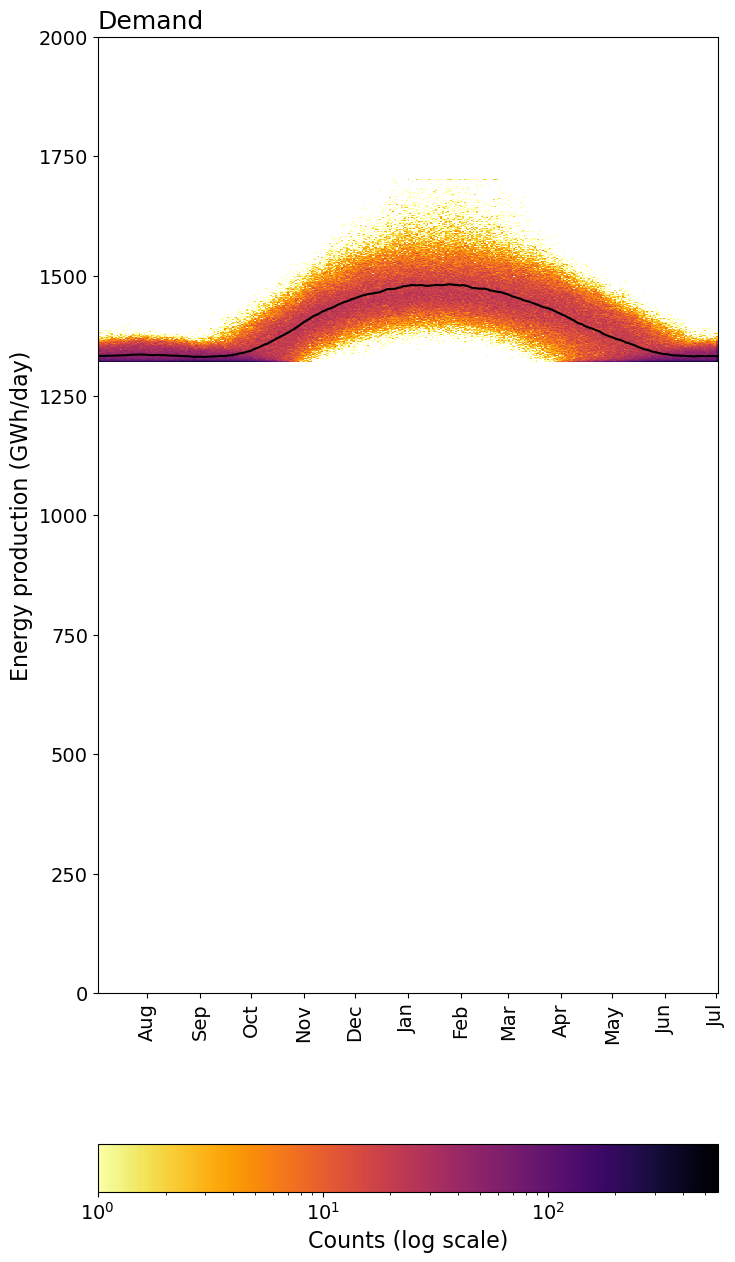

In [22]:
# --- 7) Build the figure with space for a bottom colorbar ---
fig = plt.figure(figsize=(8, 15))
gs = GridSpec(nrows=2, ncols=1,
              height_ratios=[1, 0.05],    # top row for plot, bottom for cbar
              hspace=0.3,                 # vertical space
              wspace=0.2)                 # horizontal space

# create the axis
ax = fig.add_subplot(gs[0, 0])

# plot the demand panel
# h = plot_winter_panel_with_months(ax, wind,  mean_wind_CMIP6, mean_wind_ERA5, mean_wind_SMARD, 'Wind energy production')
# h = plot_winter_panel_with_months(ax, solar, mean_solar_CMIP6, mean_solar_ERA5, mean_solar_SMARD, 'Solar energy production')
# h = plot_winter_panel_with_months(ax, total, mean_total_CMIP6, mean_total_ERA5, mean_total_SMARD, 'Total energy production')
h = plot_winter_panel_with_months_new(ax, demand, mean_demand_CMIP6, 'Demand')
# h = plot_winter_panel_with_months(ax, res_load, mean_res_load_CMIP6, mean_res_load_ERA5, mean_res_load_SMARD, 'Residual load', nr_days_in_a_bin=3)

ax.set_ylabel('Energy production (GWh/day)')

# --- 8) Now create a single colorbar axis in the bottom row ---
cax = fig.add_subplot(gs[1, 0])
cb = plt.colorbar(h[3], cax=cax, orientation='horizontal')
cb.set_label('Counts (log scale)')

ax = axes_bottom[1]   # your demand axis
# ax.set_ylim(bottom, top)   # choose bottom/top that definitely include your data
# example:
ax.set_ylim(1250, np.max(demand)*1.05)

# --- 9) Plot the thresholds as a dashed line ---
# ax.axhline(demand_thresh, ls='--', color='k', lw=1)

plt.show()

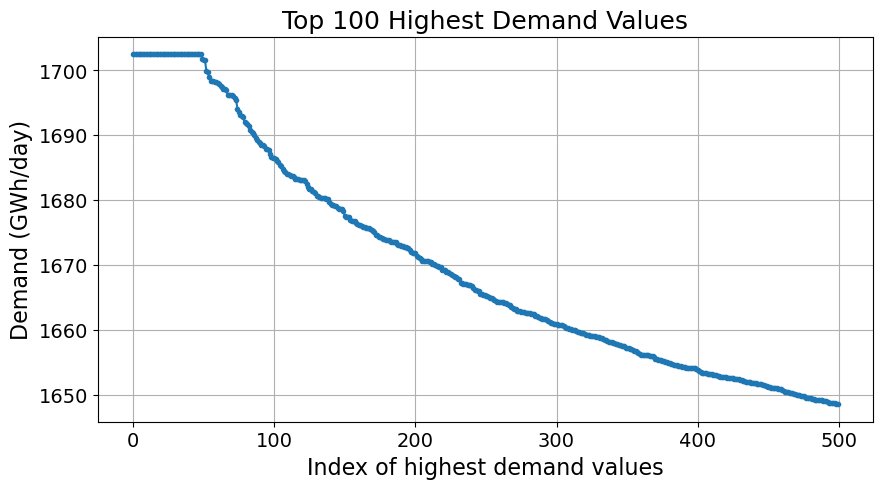

In [23]:
# Sort demand values in descending order to check the highest values
high_dem = np.sort(demand.values.flatten())[::-1]
# Plot the top 100 highest demand values
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(range(500), high_dem[:500], marker='o', markersize=3)
plt.xlabel("Index of highest demand values")
plt.ylabel("Demand (GWh/day)")
plt.title("Top 100 Highest Demand Values")
plt.grid(True)
plt.show()

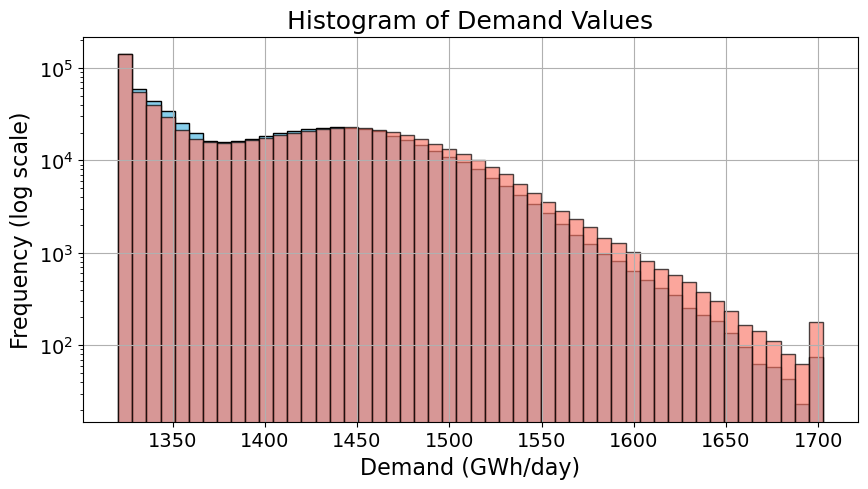

In [24]:
# Make a histogram of demand values to check the distribution
plt.figure(figsize=(10, 5))
plt.hist(demand.values.flatten(), bins=50, log=True, color='skyblue', edgecolor='black')
plt.hist(demand_curr_clim.values.flatten(), bins=50, log=True, color='salmon', edgecolor='black', alpha=0.7)
plt.xlabel("Demand (GWh/day)")
plt.ylabel("Frequency (log scale)")
plt.title("Histogram of Demand Values")
plt.grid(True)
plt.show()

In [25]:
import Functions.demand as demand_func
demand_fit_values = xr.open_dataset('/climca/people/onennecke/population_data/demand_fit_values_week.nc')

# coordinates
countries = ["DE"]
periods = ["hist"]
time = np.arange(5)

# temperature between -15 and 0 °C
temp = xr.DataArray(
    np.linspace(-15, 0, len(time)).reshape(1, 1, -1),
    dims=("country", "period", "time"),
    coords={"country": countries, "period": periods, "time": time},
    name="temp",
)

# input dataset
ds = xr.Dataset({"temp": temp})
print(ds['temp'].values)

tst = demand_func.compute_demand(ds, demand_fit_values.sel(country = 9, period = 'week'))
tst['demand'].values

[[[-15.   -11.25  -7.5   -3.75   0.  ]]]


array([[[1702.50832025, 1658.31672366, 1612.2095058 , 1566.09103113,
         1519.91570287]]])

In [26]:
# convert to pandas Series with MultiIndex (ESM_run, time)
s = demand.to_series()          # Series indexed by (ESM_run, time)

# Example: find all entries whose value matches (approximately) 1702.50832
target = 1702.50832
mask = np.isclose(s.values, target)   # use isclose to avoid float-equality issues
matches = s[mask]

# if matches.empty:
# 	print(f"No entries found with value ≈ {target}")
# else:
	# print matching entries (index shows ESM_run and time)
	# print(matches)
 
# show all rows in notebook output
pd.set_option('display.max_rows', None)
display(matches)

ESM_run                time      
EC-Earth3_r102i1p1f1   2040-01-31    1702.50832
                       2040-02-01    1702.50832
EC-Earth3_r107i1p1f1   2043-01-28    1702.50832
EC-Earth3_r108i1p1f1   2042-01-08    1702.50832
                       2042-01-25    1702.50832
                       2042-01-26    1702.50832
                       2042-01-27    1702.50832
                       2047-01-06    1702.50832
EC-Earth3_r114i1p1f1   2040-01-25    1702.50832
                       2040-01-26    1702.50832
EC-Earth3_r115i1p1f1   2039-01-01    1702.50832
                       2039-02-14    1702.50832
                       2039-02-15    1702.50832
EC-Earth3_r118i1p1f1   2046-12-24    1702.50832
EC-Earth3_r120i1p1f1   2043-02-04    1702.50832
EC-Earth3_r125i1p1f1   2045-01-08    1702.50832
                       2045-01-12    1702.50832
                       2045-01-13    1702.50832
EC-Earth3_r129i1p1f1   2043-01-13    1702.50832
                       2043-01-14    1702.50832
      

In [27]:
demand_fit_values = xr.open_dataset('/climca/people/onennecke/population_data/demand_fit_values_week.nc')
demand_fit_values.sel(country = 9, period = 'week').load()['heating_max']

<xarray.DataArray 'heating_max' ()> Size: 8B
array(1702.50832025)
Coordinates:
    country  int64 8B 9
    period   <U7 28B 'week'

### Make RL Boxplots

In [28]:
ts_datasets

<xarray.Dataset> Size: 59MB
Dimensions:        (ESM_run: 192, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL...
    country        float64 8B 9.0
    period         <U4 16B 'week'
  * time           (time) datetime64[ns] 29kB 2039-01-01 ... 2048-12-31
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 6MB 1.208 -0.303 ... 6.245 7.776
    demand         (ESM_run, time) float64 6MB 1.505e+03 1.524e+03 ... 1.422e+03
    sfcWind        (ESM_run, time) float64 6MB 4.406 6.058 5.642 ... 6.601 8.858
    rsds           (ESM_run, time) float32 3MB 23.72 30.12 26.28 ... 32.49 20.75
    tas            (ESM_run, time) float32 3MB 1.553 0.233 ... 6.191 7.687
    tasmax         (ESM_run, time) float32 3MB 2.524 1.048 ... 9.226 9.364
    wind_off_prod  (ESM_run, time) float64 6MB 92.24 77.15 30.34 ... 166.3 147.1
    wind_on_prod   (ESM_run, time) float64 6MB 153.1 321.4 ... 539.8 1.166e+03
    solar_prod     (ESM_run, time) float64 6MB 38.47 53.53 46.18 ... 61.05 37.61
    total_prod     (ESM_run, time) float64 6MB 283.8 452.1 ... 767.1 1.351e+03
    Netto          (ESM_run, time) float64 6MB -1.221e+03 -1.072e+03 ... -71.73
    Residual_load  (ESM_run, time) float64 6MB 1.221e+03 1.072e+03 ... 71.73

In [29]:
# For Boxplots per model
df = ts_datasets.to_dataframe().reset_index()

variables = [
    'Residual_load'
]
# df.loc[df['ESM'] == 'ERA5_week', 'ESM'] = 'ERA5'

# Compute ESM counts once and create labels
esm_counts = (df['ESM'].value_counts().sort_index() // 3650).astype(int)
esm_label_map = {esm: f"{esm}\n(n={count})" for esm, count in esm_counts.items()}
df['ESM_label'] = df['ESM'].map(esm_label_map)

In [30]:
# filter df for only extended winter months (ONDJFM) (based on DOY)
# filter df for only extended winter months (ONDJFM) (based on DOY)
pd.set_option('display.max_rows', 20)

winter_doys = list(range(1, 91)) + list(range(274, 366))  # Jan-Mar and Oct-Dec
df_winter = df[df['doy'].isin(winter_doys)]
df_winter

,ESM_run,time,temp,demand,sfcWind,rsds,tas,tasmax,wind_off_prod,wind_on_prod,...,Netto,Residual_load,crs,gridtype,ESM,run,country,period,doy,ESM_label
0,ACCESS-CM2_r1i1p1f1,2039-01-01,1.208366,1504.999955,4.406031,23.720234,1.553036,2.523785,92.243812,153.083395,...,-1221.200138,1221.200138,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,1,ACCESS-CM2\n(n=3)
1,ACCESS-CM2_r1i1p1f1,2039-01-02,-0.303026,1523.652017,6.058425,30.115273,0.233022,1.047754,77.147205,321.380939,...,-1071.591877,1071.591877,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,2,ACCESS-CM2\n(n=3)
2,ACCESS-CM2_r1i1p1f1,2039-01-03,-1.627460,1539.969026,5.641903,26.283237,-1.081150,-0.134251,30.339351,212.739962,...,-1250.712363,1250.712363,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,3,ACCESS-CM2\n(n=3)
3,ACCESS-CM2_r1i1p1f1,2039-01-04,-3.925736,1568.252900,4.817139,43.333614,-3.172390,-1.832053,39.407783,166.725799,...,-1284.185516,1284.185516,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,4,ACCESS-CM2\n(n=3)
4,ACCESS-CM2_r1i1p1f1,2039-01-05,-6.150842,1595.619540,4.415036,49.984737,-4.929465,-2.070846,82.519985,135.253896,...,-1285.880017,1285.880017,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,5,ACCESS-CM2\n(n=3)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700795,UKESM1-0-LL_r8i1p1f2,2048-12-27,7.179239,1430.090113,6.625254,23.002930,6.347366,9.886246,171.422920,533.531885,...,-680.801040,680.801040,4326,lonlat,UKESM1-0-LL,r8i1p1f2,9.0,week,361,UKESM1-0-LL\n(n=11)
700796,UKESM1-0-LL_r8i1p1f2,2048-12-28,8.806968,1408.770239,10.583105,19.967596,8.646202,10.673628,220.417710,1254.128126,...,100.220007,-100.220007,4326,lonlat,UKESM1-0-LL,r8i1p1f2,9.0,week,362,UKESM1-0-LL\n(n=11)
700797,UKESM1-0-LL_r8i1p1f2,2048-12-29,5.532638,1451.108105,4.949241,24.737436,5.723575,7.626062,55.726823,250.435319,...,-1106.661517,1106.661517,4326,lonlat,UKESM1-0-LL,r8i1p1f2,9.0,week,363,UKESM1-0-LL\n(n=11)
700798,UKESM1-0-LL_r8i1p1f2,2048-12-30,6.245478,1442.063144,6.600847,32.487785,6.190640,9.226201,166.290757,539.796173,...,-674.923959,674.923959,4326,lonlat,UKESM1-0-LL,r8i1p1f2,9.0,week,364,UKESM1-0-LL\n(n=11)


In [31]:
df.head()


,ESM_run,time,temp,demand,sfcWind,rsds,tas,tasmax,wind_off_prod,wind_on_prod,...,Netto,Residual_load,crs,gridtype,ESM,run,country,period,doy,ESM_label
0,ACCESS-CM2_r1i1p1f1,2039-01-01,1.208366,1504.999955,4.406031,23.720234,1.553036,2.523785,92.243812,153.083395,...,-1221.200138,1221.200138,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,1,ACCESS-CM2\n(n=3)
1,ACCESS-CM2_r1i1p1f1,2039-01-02,-0.303026,1523.652017,6.058425,30.115273,0.233022,1.047754,77.147205,321.380939,...,-1071.591877,1071.591877,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,2,ACCESS-CM2\n(n=3)
2,ACCESS-CM2_r1i1p1f1,2039-01-03,-1.627460,1539.969026,5.641903,26.283237,-1.081150,-0.134251,30.339351,212.739962,...,-1250.712363,1250.712363,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,3,ACCESS-CM2\n(n=3)
3,ACCESS-CM2_r1i1p1f1,2039-01-04,-3.925736,1568.252900,4.817139,43.333614,-3.172390,-1.832053,39.407783,166.725799,...,-1284.185516,1284.185516,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,4,ACCESS-CM2\n(n=3)
4,ACCESS-CM2_r1i1p1f1,2039-01-05,-6.150842,1595.619540,4.415036,49.984737,-4.929465,-2.070846,82.519985,135.253896,...,-1285.880017,1285.880017,4326,lonlat,ACCESS-CM2,r1i1p1f1,9.0,week,5,ACCESS-CM2\n(n=3)


In [19]:
183000   *2

366000

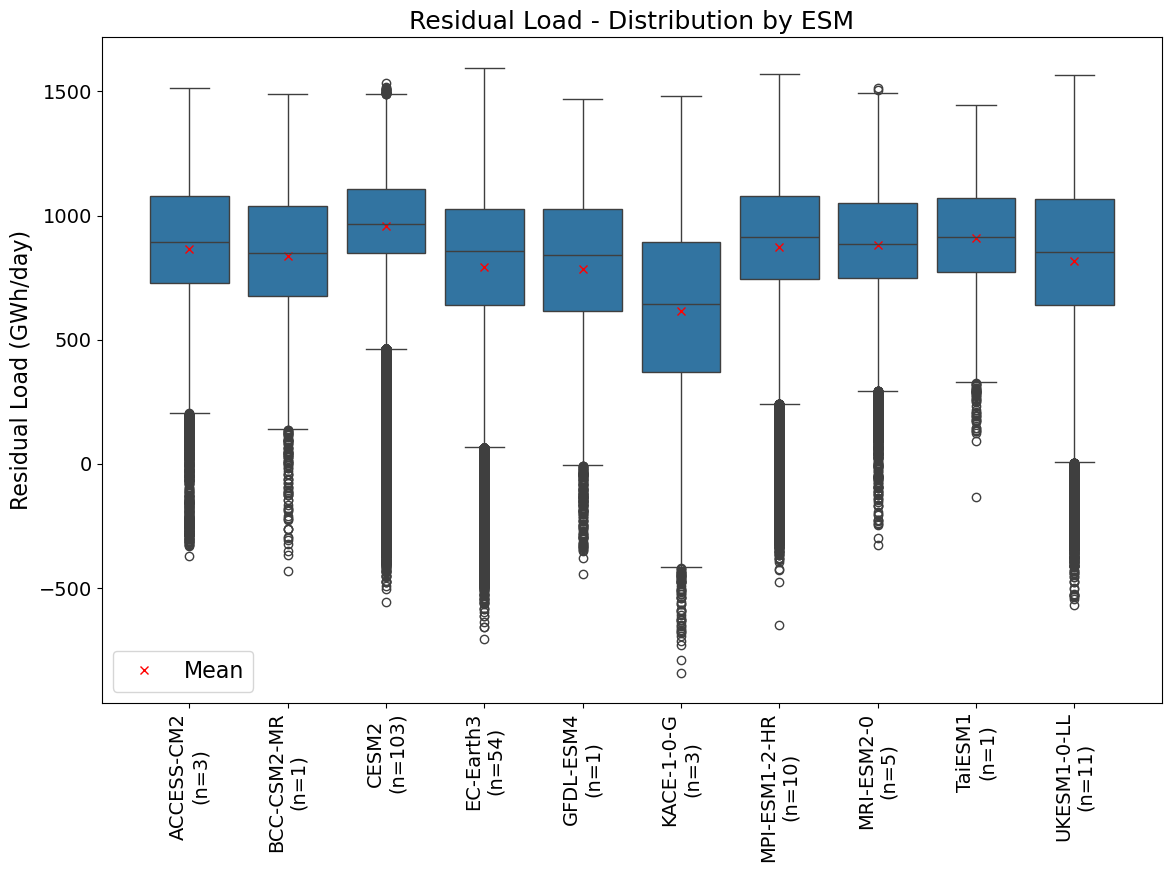

In [32]:
# Single boxplot for variable "res_load"
# make text bigger (global)
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})


var = 'Residual_load'
display_var = var  # change if you want a prettier label

# determine order so ERA5 (if present) is first
labels = list(df['ESM_label'].unique())
# era5_candidates = [lab for lab in labels if 'ERA5' in str(lab)]
# if era5_candidates:
#     era5_label = era5_candidates[0]
#     order = [era5_label] + [lab for lab in labels if lab != era5_label]
# else:
order = labels

fig, ax = plt.subplots(figsize=(8*3/2, 6*3/2))
sns.boxplot(data=df, x='ESM_label', y=var, order=order, ax=ax)

# plot means at categorical x positions
means = df.groupby('ESM_label')[var].mean().reindex(order)
x_positions = np.arange(len(order))
ax.plot(x_positions, means.values, color='red', marker='x', linestyle='', label='Mean')

# dashed vertical separator between ERA5 (pos 0) and the rest
# if len(order) > 1:
#     ax.axvline(x=0.5, color="#7A7878", linestyle='-.', linewidth=1)

# horizontal ERA5_hist mean (if ts_datasets exists and contains ERA5_hist)
if 'ts_datasets' in globals():
    try:
        era5_hist_val = ts_datasets[var].sel(ESM_run='ERA5_hist').mean('time')
        ax.axhline(y=float(era5_hist_val), color='black', linestyle='--', linewidth=1, label='ERA5 mean')
    except Exception:
        # either var not present or ERA5_hist missing — ignore silently
        pass

ax.set_title('Residual Load - Distribution by ESM')
ax.tick_params(axis='x', rotation=90)
ax.set_xlabel('')

# use units dict if available
# unit = units.get(var, '') if 'units' in globals() else ''
ax.set_ylabel('Residual Load (GWh/day)')

ax.legend(loc='lower left')
plt.tight_layout()
# Save
# plt.savefig('/home/onennecke/Code/Figures/RL_bxplt_per_ESM.png', bbox_inches='tight', dpi=300)

plt.show()


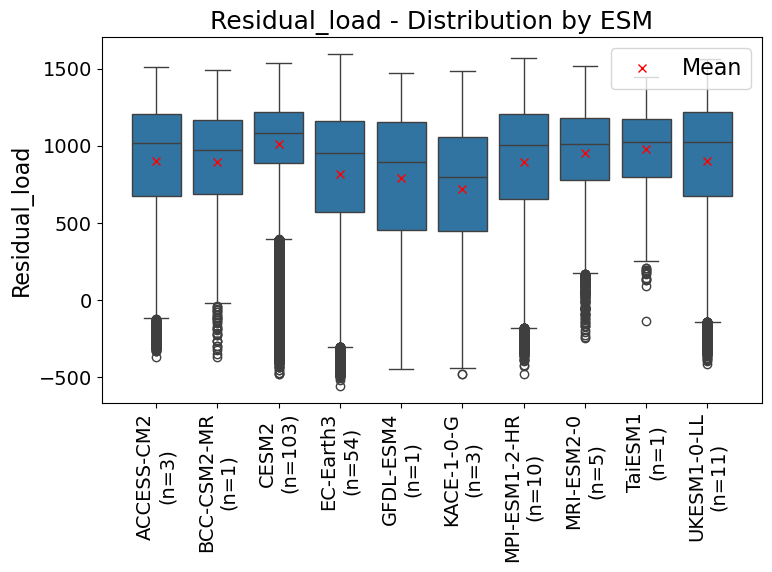

In [30]:
# Same for extended winter months only

# Single boxplot for variable "res_load"

var = 'Residual_load'
display_var = var  # change if you want a prettier label

# determine order so ERA5 (if present) is first
labels = list(df_winter['ESM_label'].unique())
era5_candidates = [lab for lab in labels if 'ERA5' in str(lab)]
if era5_candidates:
    era5_label = era5_candidates[0]
    order = [era5_label] + [lab for lab in labels if lab != era5_label]
else:
    order = labels

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df_winter, x='ESM_label', y=var, order=order, ax=ax)

# plot means at categorical x positions
means = df_winter.groupby('ESM_label')[var].mean().reindex(order)
x_positions = np.arange(len(order))
ax.plot(x_positions, means.values, color='red', marker='x', linestyle='', label='Mean')

# dashed vertical separator between ERA5 (pos 0) and the rest
# if len(order) > 1:
#     ax.axvline(x=0.5, color="#7A7878", linestyle='-.', linewidth=1)

# horizontal ERA5_hist mean (if ts_datasets exists and contains ERA5_hist)
if 'ts_datasets' in globals():
    try:
        era5_hist_val = ts_datasets[var].sel(ESM_run='ERA5_hist').mean('time')
        ax.axhline(y=float(era5_hist_val), color='black', linestyle='--', linewidth=1, label='ERA5 mean')
    except Exception:
        # either var not present or ERA5_hist missing — ignore silently
        pass

ax.set_title(f'{display_var} - Distribution by ESM')
ax.tick_params(axis='x', rotation=90)
ax.set_xlabel('')

# use units dict if available
# unit = units.get(var, '') if 'units' in globals() else ''
# ax.set_ylabel(f'{display_var} ({unit})' if unit else display_var)

ax.legend(loc='upper right')
plt.tight_layout()
plt.show()
